# Actividad:SVM (Breast Cancer)



**Objetivo:** aplicar SVM a un conjunto de datos real (Breast Cancer Wisconsin) y comparar:
- **SVM lineal** vs **SVM con kernel RBF**
- Ver los efectos del **escalado**
- Evaluación con métricas y matrices de confusión
- Breast Cancer Wiscosin está incluido en sklearn. Puedes encontrarlo [aquí](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)


**SVC** es la clase que:

- se instancia para crear el modelo (svm_lineal, svm_rbf),

- se entrena con fit,

- se usa para predecir con predict.

In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Carga y estudio del conjunto de datos

El conjunto **Breast Cancer Wisconsin** es un dataset real de clasificación binaria. El objetivo es predecir si un tumor es **maligno** o **benigno** a partir de características numéricas.

En esta celda:
- cargaremos los datos,
- revisaremos dimensiones,
- comprobaremos la distribución de clases.

| Variable | Qué representa                         |
| -------- | -------------------------------------- |
| `data`   | Dataset completo (datos + metadatos)   |
| `X`      | Variables de entrada (características) |
| `y`      | Variable objetivo (clase)              |


In [55]:
df_cancer = load_breast_cancer(as_frame=True).frame
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [56]:
data = load_breast_cancer()

X = data.data 
y = data.target 

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Nombres de clases: {data.target_names}")

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)
Nombres de clases: ['malignant' 'benign']


### Vista rápida de algunas características

Mostramos las 5 primeras filas para ver el tipo de datos.

df es un DataFrame de pandas que ya contiene las características (X).

'target' es el nombre de la nueva columna que se va a crear.

y es el vector de etiquetas (la clase de cada muestra).
tras ejecutar la siguiente celda tendremos:   
columnas → características + target

filas → cada muestra con:

sus variables

su clase (0 o 1)

### Distribución de clases

En problemas de clasificación es importante verificar si hay **desbalanceo**.
El desbalanceo indica si hay equilibrio entre los datos que hay correspondientes a cada clase
Estudiando la gráfica comprobamos si hay un número parecido de casos en cada categoría

Distribución de clases: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


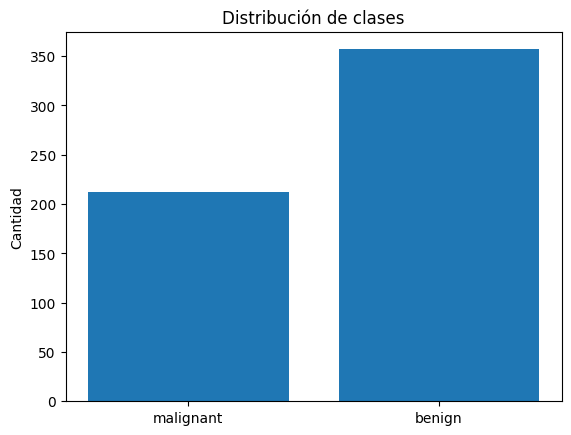

In [57]:
unique, counts = np.unique(y, return_counts=True)
print(f"Distribución de clases: {dict(zip(data.target_names, counts))}")

plt.bar(data.target_names, counts)
plt.title('Distribución de clases')
plt.ylabel('Cantidad')
plt.show()

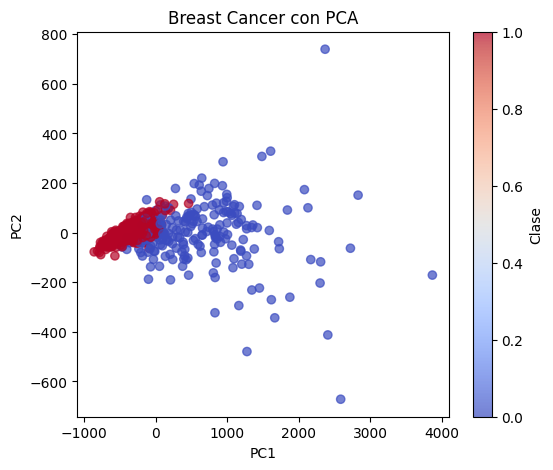

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Breast Cancer con PCA")
plt.colorbar(label="Clase")
plt.show()


## 2. Preparación de datos: Train/Test y escalado

Dividimos en entrenamiento y prueba usando `stratify=y` para mantener la proporción de clases. Después, aplicaremos **StandardScaler** (media 0, desviación 1).=> estandarizamos (aunque coloquialmente podeos decir normalizamos)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (426, 30), Test: (143, 30)


In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Entrenamiento y evaluación de modelos SVM

Entrenaremos dos modelos:
- **SVM lineal** 
- **SVM RBF** (no lineal)

Evaluaremos con:
- accuracy -> exhaustividad
- matriz de confusión
- classification report -> Muestra varias métricas: Precision, Recall(De todos los casos reales de esa clase, ¿cuántos ha detectado el modelo?),
- F1-score


### 3.1 SVM con kernel lineal

Usamos **C=1** como valor base (es un buen inicio).

In [60]:
svm_lineal = SVC(kernel="linear", C=1.0, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [61]:
pred_lineal = svm_lineal.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_lineal)) 
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))

Accuracy: 0.986013986013986
[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



### 3.2 SVM con kernel RBF

Probaremos un primer modelo con valores razonables de C y gamma. Después, probaremos más combinaciones

In [62]:
svm_rbf = SVC(kernel="rbf", C=5.0, gamma=2.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",2.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [63]:
pred_rbf = svm_rbf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))

Accuracy: 0.6293706293706294
[[ 0 53]
 [ 0 90]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.63      1.00      0.77        90

    accuracy                           0.63       143
   macro avg       0.31      0.50      0.39       143
weighted avg       0.40      0.63      0.49       143



c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

### 3.3 Ajuste manual básico

Probamos algunas combinaciones de **C** y **gamma** y guardamos la mejor según **accuracy** en test. 

In [64]:
svm_rbf_1 = SVC(kernel="rbf", C=5.0, gamma=0.01, random_state=42)
svm_rbf_1.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [65]:
pred_rbf_1 = svm_rbf_1.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_rbf_1))
print(confusion_matrix(y_test, pred_rbf_1))
print(classification_report(y_test, pred_rbf_1))

Accuracy: 0.986013986013986
[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [66]:
y_pred = svm_rbf_1.predict(X_test_scaled)

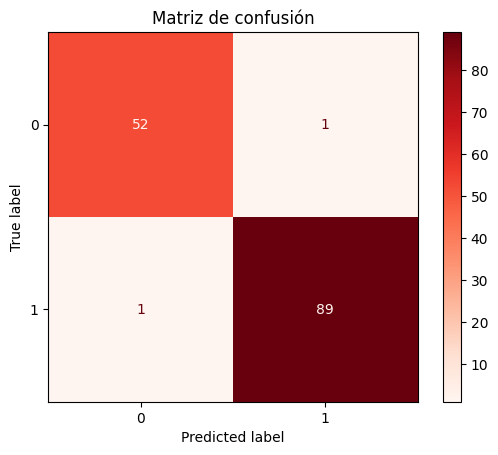

Accuracy:  0.986013986013986
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión")
plt.show()


# Porcentaje de predicciones que hace bien
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [68]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

valores_C = [0.1, 1, 5, 10, 50, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]

mejor_acc = 0
mejor_config = None

# Bucle para probar varias combinaciones de C y gamma para comprobar cual da el mejor accuracy
for C in valores_C:
    for gamma in valores_gamma:
        print(f"\nProbando C={C} | gamma={gamma}")
        
        svm_rbf = SVC(kernel="rbf", C=C, gamma=gamma, random_state=42)
        svm_rbf.fit(X_train_scaled, y_train)

        pred = svm_rbf.predict(X_test_scaled)
        acc = accuracy_score(y_test, pred)

        print(f"Accuracy: {acc:.4f}")

        if acc > mejor_acc:
            mejor_acc = acc
            mejor_config = (C, gamma)



Probando C=0.1 | gamma=0.001
Accuracy: 0.7762

Probando C=0.1 | gamma=0.01
Accuracy: 0.9441

Probando C=0.1 | gamma=0.1
Accuracy: 0.9441

Probando C=0.1 | gamma=1


Accuracy: 0.6294

Probando C=1 | gamma=0.001
Accuracy: 0.9441

Probando C=1 | gamma=0.01
Accuracy: 0.9720

Probando C=1 | gamma=0.1
Accuracy: 0.9720

Probando C=1 | gamma=1
Accuracy: 0.6294

Probando C=5 | gamma=0.001
Accuracy: 0.9510

Probando C=5 | gamma=0.01
Accuracy: 0.9860

Probando C=5 | gamma=0.1
Accuracy: 0.9720

Probando C=5 | gamma=1
Accuracy: 0.6364

Probando C=10 | gamma=0.001
Accuracy: 0.9790

Probando C=10 | gamma=0.01
Accuracy: 0.9790

Probando C=10 | gamma=0.1
Accuracy: 0.9580

Probando C=10 | gamma=1
Accuracy: 0.6364

Probando C=50 | gamma=0.001
Accuracy: 0.9860

Probando C=50 | gamma=0.01
Accuracy: 0.9790

Probando C=50 | gamma=0.1
Accuracy: 0.9510

Probando C=50 | gamma=1
Accuracy: 0.6364

Probando C=100 | gamma=0.001
Accuracy: 0.9860

Probando C=100 | gamma=0.01
Accuracy: 0.9720

Probando C=100 | gamma=0.1
Accuracy: 0.9510

Probando C=100 | gamma=1
Accuracy: 0.6364


In [69]:
print(f"Mejor Accuracy: {mejor_acc:.4f}")
print(f"Mejor C y gamma: C={mejor_config[0]}, gamma={mejor_config[1]}")

Mejor Accuracy: 0.9860
Mejor C y gamma: C=5, gamma=0.01


## 4. Resumen

Responde brevemente:
1. ¿Qué modelo ha rendido mejor, lineal o RBF?
2. ¿Cómo cambia el rendimiento al variar C y gamma?
3. ¿Por qué es importante el escalado en SVM?

> *Sugerencia:* apóyate en la matriz de confusión y en el classification report.